# Functions

Este bloco define as funções principais para simular o **código de Shor em Qiskit**. Ele prepara um estado quântico inicial, codifica esse estado em nove qubits físicos, aplica erros controlados dos tipos $X$, $Y$ e $Z$, calcula a síndrome por meio dos estabilizadores e constrói o circuito de recuperação correspondente. Ao final, a função `run_shor_case` compara o estado ideal com o estado corrigido usando a fidelidade, permitindo avaliar se o erro aplicado foi corretamente identificado e corrigido. 


In [1]:
# ============================================================
# Simulação do Código de Shor em Qiskit
# Erros controlados: X, Y e Z
# ============================================================
# Instalação sugerida, caso necessário:
# !pip install qiskit qiskit-aer pandas matplotlib pylatexenc

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, SparsePauliOp, state_fidelity
from qiskit_aer import AerSimulator
import pandas as pd

# ------------------------------------------------------------
# Funções auxiliares
# ------------------------------------------------------------

def pauli_label(pauli, qubits, n = 9):
    """
    Cria uma string de Pauli compatível com a convenção do Qiskit.
    No Qiskit, o caractere mais à direita atua no qubit 0.
    """
    label = ["I"] * n
    for q in qubits:
        label[n - 1 - q] = pauli
    return "".join(label)


def stabilizer_operator(label):
    """
    Constrói um operador estabilizador a partir de uma string de Pauli.
    """
    return SparsePauliOp.from_list([(label, 1.0)])


def expectation_sign(state, label, tol=1e-8):
    """
    Calcula o sinal esperado de um estabilizador.
    Retorna +1 ou -1.
    """
    value = state.expectation_value(stabilizer_operator(label)).real
    if value >= -tol:
        return +1
    return -1


# ------------------------------------------------------------
# Preparação e codificação do código de Shor
# ------------------------------------------------------------

def prepare_initial_state(qc, theta=0.73, phi=0.41):
    """
    Prepara um estado inicial genérico no qubit 0.
    O uso de RY e RZ evita escolher um autoestado trivial de X ou Z.
    """
    qc.ry(theta, 0)
    qc.rz(phi, 0)
    qc.barrier()


def encode_shor(qc):
    """
    Codifica um qubit lógico em nove qubits físicos usando o código de Shor.
    """
    # Redundância entre os três blocos principais
    qc.cx(0, 3)
    qc.cx(0, 6)
    # Mudança de base para proteção contra erros de fase
    qc.h(0)
    qc.h(3)
    qc.h(6)
    # Codificação tipo repetição dentro de cada bloco de três qubits
    qc.cx(0, 1)
    qc.cx(0, 2)
    qc.cx(3, 4)
    qc.cx(3, 5)
    qc.cx(6, 7)
    qc.cx(6, 8)
    qc.barrier()


def build_encoded_circuit():
    """
    Constrói o circuito codificado ideal, sem erro.
    """
    qc = QuantumCircuit(N_QUBITS)
    prepare_initial_state(qc)
    encode_shor(qc)
    return qc


# ------------------------------------------------------------
# Inserção controlada de erro
# ------------------------------------------------------------

def apply_pauli_error(qc, error_type, error_qubit):
    """
    Aplica um erro de Pauli controlado no circuito.
    error_type deve ser 'X', 'Y' ou 'Z'.
    """
    error_type = error_type.upper()
    if error_type == "X":
        qc.x(error_qubit)
    elif error_type == "Y":
        qc.y(error_qubit)
    elif error_type == "Z":
        qc.z(error_qubit)
    else:
        raise ValueError("O erro deve ser 'X', 'Y' ou 'Z'.")
    qc.barrier()


def build_error_circuit(error_type, error_qubit):
    """
    Constrói o circuito codificado com um erro de Pauli inserido.
    """
    qc = build_encoded_circuit()
    apply_pauli_error(qc, error_type, error_qubit)
    return qc


# ------------------------------------------------------------
# Síndrome e recuperação
# ------------------------------------------------------------

def compute_syndrome(state):
    """
    Calcula a síndrome associada aos estabilizadores do código de Shor.
    """
    syndrome = {}
    for name, label in STABILIZERS.items():
        syndrome[name] = expectation_sign(state, label)
    return syndrome


def infer_x_error_from_syndrome(syndrome):
    """
    Identifica erro X usando os pares de estabilizadores Z dentro de cada bloco.
    """
    block_syndromes = [
        (syndrome["Z0Z1"], syndrome["Z1Z2"]),
        (syndrome["Z3Z4"], syndrome["Z4Z5"]),
        (syndrome["Z6Z7"], syndrome["Z7Z8"]),
    ]
    for block_index, pair in enumerate(block_syndromes):
        base = 3 * block_index
        if pair == (-1, +1):
            return base
        if pair == (-1, -1):
            return base + 1
        if pair == (+1, -1):
            return base + 2
    return None


def infer_z_error_from_syndrome(syndrome):
    """
    Identifica o bloco afetado por erro Z usando os estabilizadores X.
    A recuperação pode ser aplicada em qualquer qubit representativo do bloco.
    """
    pair = (
        syndrome["X0X1X2X3X4X5"],
        syndrome["X3X4X5X6X7X8"],
    )
    if pair == (-1, +1):
        return 0  # bloco 0: qubits 0, 1, 2
    if pair == (-1, -1):
        return 3  # bloco 1: qubits 3, 4, 5
    if pair == (+1, -1):
        return 6  # bloco 2: qubits 6, 7, 8
    return None


def build_recovery_circuit(syndrome):
    """
    Constrói o circuito de recuperação a partir da síndrome.
    """
    recovery = QuantumCircuit(N_QUBITS)
    x_qubit = infer_x_error_from_syndrome(syndrome)
    z_qubit = infer_z_error_from_syndrome(syndrome)
    if x_qubit is not None:
        recovery.x(x_qubit)
    if z_qubit is not None:
        recovery.z(z_qubit)
    return recovery, x_qubit, z_qubit


# ------------------------------------------------------------
# Execução de um caso de teste
# ------------------------------------------------------------

def run_shor_case(error_type, error_qubit):
    """
    Executa a simulação para um erro específico aplicado em um qubit específico.
    """
    # Estado codificado ideal
    ideal_circuit = build_encoded_circuit()
    ideal_state = Statevector.from_instruction(ideal_circuit)
    # Estado com erro
    error_circuit = build_error_circuit(error_type, error_qubit)
    error_state = Statevector.from_instruction(error_circuit)
    # Síndrome
    syndrome = compute_syndrome(error_state)
    # Recuperação
    recovery_circuit, x_recovery, z_recovery = build_recovery_circuit(syndrome)
    corrected_state = error_state.evolve(recovery_circuit)
    # Fidelidades
    fidelity_before = state_fidelity(ideal_state, error_state)
    fidelity_after = state_fidelity(ideal_state, corrected_state)
    return {
        "erro_aplicado": error_type,
        "qubit_afetado": error_qubit,
        "recuperacao_X_no_qubit": x_recovery,
        "recuperacao_Z_no_qubit": z_recovery,
        "fidelidade_antes": fidelity_before,
        "fidelidade_depois": fidelity_after,
        "sindrome": syndrome,
        "circuito_com_erro": error_circuit,
        "circuito_recuperacao": recovery_circuit,
    }

# Definição do número de qubits

Este bloco define os **parâmetros principais da simulação** e executa os três testes centrais do código de Shor. Primeiro, fixa-se `N_QUBITS = 9`, pois o código de Shor codifica um qubit lógico em **nove qubits físicos**. Em seguida, são definidos os estabilizadores `STABILIZERS`: os operadores do tipo `Z` detectam erros de bit-flip, isto é, erros $X$, dentro de cada bloco de três qubits; já os operadores do tipo `X` detectam erros de fase, isto é, erros $Z$, entre os blocos. Depois, a lista `cases` define os experimentos principais: aplicar separadamente erros $X$, $Y$ e $Z$ no qubit físico 4. Para cada caso, a função `run_shor_case` executa a simulação, calcula a síndrome, aplica a correção correspondente e retorna as fidelidades antes e depois da recuperação. Por fim, os resultados são organizados em um `DataFrame`, permitindo comparar, para cada tipo de erro, o qubit afetado, as correções aplicadas e a fidelidade final do estado lógico corrigido.


In [2]:
N_QUBITS = 9

# ------------------------------------------------------------
# Estabilizadores do código de Shor
# ------------------------------------------------------------

STABILIZERS = {
    # Estabilizadores Z para detectar erros X dentro dos blocos
    "Z0Z1": pauli_label("Z", [0, 1]),
    "Z1Z2": pauli_label("Z", [1, 2]),

    "Z3Z4": pauli_label("Z", [3, 4]),
    "Z4Z5": pauli_label("Z", [4, 5]),

    "Z6Z7": pauli_label("Z", [6, 7]),
    "Z7Z8": pauli_label("Z", [7, 8]),

    # Estabilizadores X para detectar erros Z entre os blocos
    "X0X1X2X3X4X5": pauli_label("X", [0, 1, 2, 3, 4, 5]),
    "X3X4X5X6X7X8": pauli_label("X", [3, 4, 5, 6, 7, 8]),
}

# ------------------------------------------------------------
# Experimentos principais: X, Y e Z
# ------------------------------------------------------------

cases = [
    ("X", 4),
    ("Y", 4),
    ("Z", 4),
]
results = []
for error_type, error_qubit in cases:
    output = run_shor_case(error_type, error_qubit)
    results.append({
        "Erro": output["erro_aplicado"],
        "Qubit afetado": output["qubit_afetado"],
        "Correção X": output["recuperacao_X_no_qubit"],
        "Correção Z": output["recuperacao_Z_no_qubit"],
        "Fidelidade antes": output["fidelidade_antes"],
        "Fidelidade depois": output["fidelidade_depois"],
    })
df_results = pd.DataFrame(results)
df_results

,Erro,Qubit afetado,Correção X,Correção Z,Fidelidade antes,Fidelidade depois
0,X,4,4.0,NaN,0.000000e+00,1.0
1,Y,4,4.0,3.0,0.000000e+00,1.0
2,Z,4,NaN,3.0,1.880791e-37,1.0


# Funções auxiliares para operadores de Pauli

Este bloco define os **estabilizadores do código de Shor** e executa os experimentos principais da simulação. Os estabilizadores com operadores `Z`, como `Z0Z1` e `Z1Z2`, são usados para detectar erros do tipo $X$, isto é, erros de inversão de bit dentro de cada bloco de três qubits. Já os estabilizadores com operadores `X`, como `X0X1X2X3X4X5`, são usados para detectar erros do tipo $Z$, associados à inversão de fase entre os blocos. Em seguida, a lista `cases` define três testes: aplicação de erros $X$, $Y$ e $Z$ no qubit físico 4. Para cada erro, a função `run_shor_case` executa a simulação, calcula a síndrome, determina a correção necessária e retorna as fidelidades antes e depois da recuperação. Por fim, os resultados são organizados em um `DataFrame`, permitindo comparar o efeito de cada erro e verificar se o código de Shor recuperou corretamente o estado lógico.

In [3]:
# ------------------------------------------------------------
# Estabilizadores do código de Shor
# ------------------------------------------------------------

STABILIZERS = {
    # Estabilizadores Z para detectar erros X dentro dos blocos
    "Z0Z1": pauli_label("Z", [0, 1]),
    "Z1Z2": pauli_label("Z", [1, 2]),
    "Z3Z4": pauli_label("Z", [3, 4]),
    "Z4Z5": pauli_label("Z", [4, 5]),
    "Z6Z7": pauli_label("Z", [6, 7]),
    "Z7Z8": pauli_label("Z", [7, 8]),
    # Estabilizadores X para detectar erros Z entre os blocos
    "X0X1X2X3X4X5": pauli_label("X", [0, 1, 2, 3, 4, 5]),
    "X3X4X5X6X7X8": pauli_label("X", [3, 4, 5, 6, 7, 8]),
}

# ------------------------------------------------------------
# Experimentos principais: X, Y e Z
# ------------------------------------------------------------

cases = [
    ("X", 4),
    ("Y", 4),
    ("Z", 4),
]
results = []
for error_type, error_qubit in cases:
    output = run_shor_case(error_type, error_qubit)
    results.append({
        "Erro": output["erro_aplicado"],
        "Qubit afetado": output["qubit_afetado"],
        "Correção X": output["recuperacao_X_no_qubit"],
        "Correção Z": output["recuperacao_Z_no_qubit"],
        "Fidelidade antes": output["fidelidade_antes"],
        "Fidelidade depois": output["fidelidade_depois"],
    })
df_results = pd.DataFrame(results)
df_results

,Erro,Qubit afetado,Correção X,Correção Z,Fidelidade antes,Fidelidade depois
0,X,4,4.0,NaN,0.000000e+00,1.0
1,Y,4,4.0,3.0,0.000000e+00,1.0
2,Z,4,NaN,3.0,1.880791e-37,1.0


# Definição dos estabilizadores do código de Shor

Este bloco gera um **exemplo visual do circuito quântico com erro**. Primeiro, a linha `run_shor_case("X", 4)` executa a simulação de um caso específico em que um erro do tipo $X$ é aplicado ao **qubit 4**. O resultado é armazenado na variável `example`, que contém várias informações da simulação, como o circuito com erro, o circuito de recuperação, a síndrome e as fidelidades. Em seguida, `example["circuito_com_erro"].draw("mpl", fold=120)` desenha graficamente o **circuito quântico com o erro inserido**, usando o backend de visualização do Matplotlib. O parâmetro `fold=120` controla a quebra de linha do circuito, deixando a figura mais legível. Em resumo, este bloco serve para **visualizar o circuito codificado após a introdução de um erro $X$ no qubit 4**, facilitando a documentação e a análise da implementação.

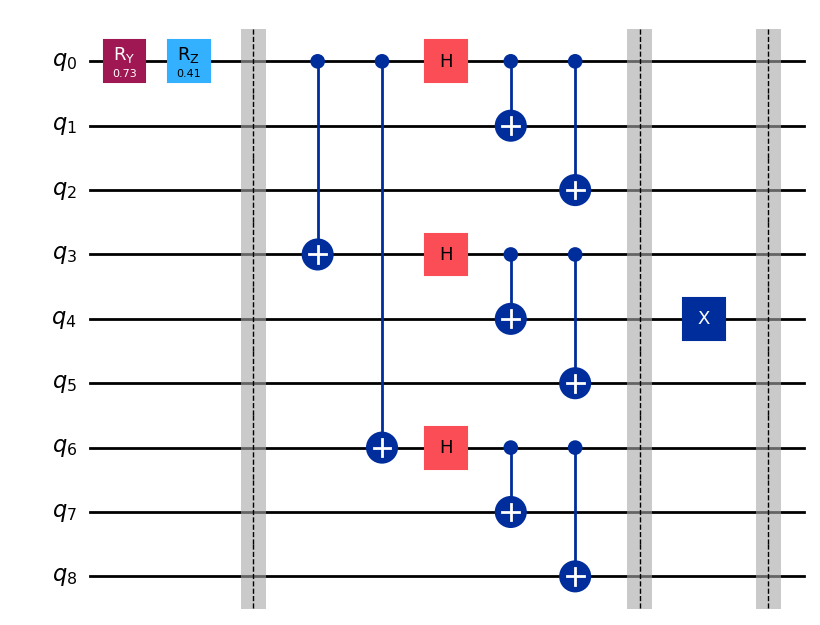

In [4]:
# Exemplo: circuito com erro X aplicado no qubit 4
example = run_shor_case("X", 4)
example["circuito_com_erro"].draw("mpl", fold=120)

# Preparação do estado inicial

Este bloco desenha o **circuito de recuperação** obtido a partir da síndrome de erro calculada anteriormente. A expressão `example["circuito_recuperacao"]` acessa, dentro do dicionário `example`, o circuito que contém apenas as **portas corretivas** aplicadas para recuperar o estado lógico após o erro introduzido. Em seguida, o comando `.draw("mpl", fold=120)` gera a representação gráfica desse circuito usando Matplotlib. Em termos práticos, esse circuito mostra **quais operações de correção foram aplicadas** ao sistema, por exemplo uma porta $X$, uma porta $Z$, ou ambas, dependendo do erro detectado. Assim, este bloco é útil para visualizar de forma explícita o procedimento de correção executado pelo código de Shor.

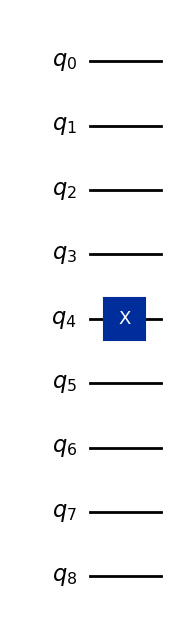

In [5]:
example["circuito_recuperacao"].draw("mpl", fold=120)

# Codificação do qubit lógico pelo código de Shor

Este bloco executa o **circuito completo no simulador Aer**. Primeiro, cria-se o simulador com `AerSimulator()`. Em seguida, o circuito com erro é combinado com o circuito de recuperação usando `.compose()`, formando um único circuito que contém a codificação, a introdução do erro e a correção. Depois, `measure_all()` adiciona medições a todos os qubits, permitindo observar os resultados finais da simulação. O circuito é então compilado para o simulador com `transpile`, executado com `1024` repetições e os resultados são extraídos por meio de `get_counts()`. Em resumo, este bloco simula experimentalmente o circuito corrigido e retorna a distribuição de contagens dos estados medidos, permitindo verificar o comportamento final do sistema após a aplicação da correção de erro.

In [6]:
simulator = AerSimulator()

full_circuit = example["circuito_com_erro"].compose(
    example["circuito_recuperacao"]
)

full_circuit.measure_all()

compiled_circuit = transpile(full_circuit, simulator)

job = simulator.run(compiled_circuit, shots=1024)
counts = job.result().get_counts()

counts

{'111111000': 192,
 '000000111': 38,
 '111000111': 218,
 '000111000': 57,
 '111000000': 50,
 '000000000': 186,
 '000111111': 240,
 '111111111': 43}